# XGBoost feature-set comparison and tuning diagnostics

The three nested feature sets are first compared under a common XGBoost configuration. The selected information set is then examined under three controlled configurations using the chronological validation sample. The test sample is not used.

Initial parameters:

- learning rate: 0.05;
- maximum tree depth: 3;
- minimum child weight: 1;
- row subsampling fraction: 0.80;
- column subsampling fraction: 0.80;
- squared-error training objective;
- MAE validation metric;
- maximum boosting rounds: 1,000;
- early-stopping patience: 30 rounds;
- histogram tree method; and
- random seed: 42.

The second configuration raises the learning rate to 0.10, while the third also increases maximum depth from 3 to 4.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator, PercentFormatter
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.tabular_selection import (
    TARGET,
    XGBOOST_MAX_ROUNDS,
    XGBOOST_PATIENCE,
    fit_preprocessor,
    load_sample,
    performance,
    split_sample,
    transform_features,
)
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()

## Feature-set comparison under a common configuration

Market, ownership-augmented, and network-augmented specifications are estimated with identical XGBoost settings. Early stopping determines the number of boosting rounds separately for each specification.

,feature_set,predictors,best_round,training_mae,validation_mae,generalization_gap,validation_rmse,validation_r2,mean_quarterly_spearman
0,Market,7,176,0.0836,0.0950,0.0114,0.1317,0.466,0.749
1,Market + ownership,12,175,0.0833,0.0943,0.0110,0.1305,0.475,0.751
2,Market + ownership + network,18,140,0.0835,0.0946,0.0111,0.1306,0.474,0.750


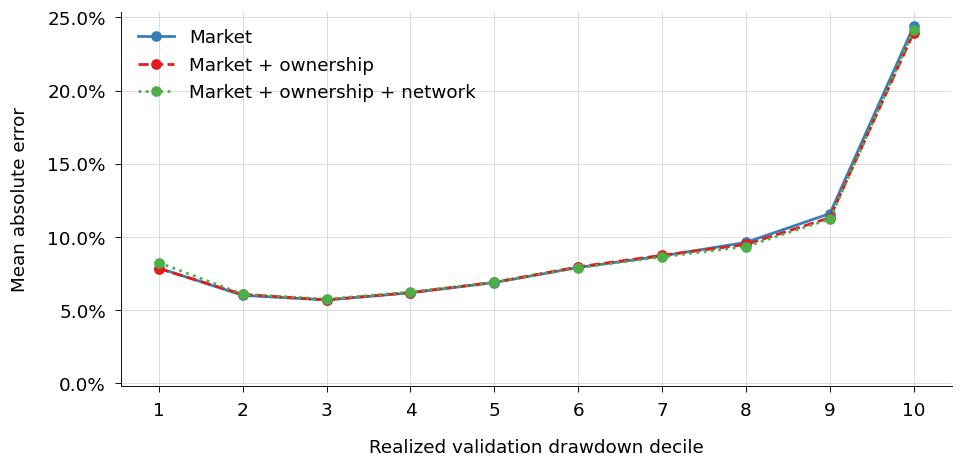

In [8]:
feature_sets = {
    'market': 'Market',
    'augmented': 'Market + ownership',
    'network_augmented': 'Market + ownership + network',
}
feature_rows = []
feature_validation_predictions = []
for feature_group, label in feature_sets.items():
    feature_sample = load_sample(
        paths.processed / 'modeling' / 'network_modeling_sample.parquet',
        feature_group,
    )
    feature_train, feature_validation, _ = split_sample(feature_sample)
    preprocessing = fit_preprocessor(
        feature_train, feature_group, standardize=False
    )
    feature_train_x = transform_features(feature_train, preprocessing)
    feature_validation_x = transform_features(
        feature_validation, preprocessing
    )
    model = XGBRegressor(
        n_estimators=XGBOOST_MAX_ROUNDS, max_depth=3,
        min_child_weight=1, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', eval_metric='mae',
        early_stopping_rounds=XGBOOST_PATIENCE,
        random_state=project.seed, n_jobs=4, tree_method='hist',
        verbosity=0,
    )
    model.fit(
        feature_train_x, feature_train[TARGET],
        eval_set=[
            (feature_train_x, feature_train[TARGET]),
            (feature_validation_x, feature_validation[TARGET]),
        ],
        verbose=False,
    )
    train_predictions = np.clip(model.predict(feature_train_x), 0, 1)
    validation_predictions = np.clip(
        model.predict(feature_validation_x), 0, 1
    )
    metrics = performance(
        stage='xgboost_feature_comparison',
        model=f'xgboost_{feature_group}', model_class='xgboost',
        feature_group=feature_group, sample=feature_validation,
        predictions=validation_predictions,
    )
    feature_rows.append({
        'feature_set': label,
        'predictors': feature_train_x.shape[1],
        'best_round': int(model.best_iteration) + 1,
        'training_mae': mean_absolute_error(
            feature_train[TARGET], train_predictions
        ),
        **metrics,
    })
    prediction_frame = feature_validation[[
        'report_period', 'permno', TARGET
    ]].copy()
    prediction_frame['feature_set'] = label
    prediction_frame['prediction'] = validation_predictions
    feature_validation_predictions.append(prediction_frame)

xgboost_feature_comparison = pd.DataFrame(feature_rows).rename(columns={
    'mae': 'validation_mae', 'rmse': 'validation_rmse',
    'r2': 'validation_r2',
})
xgboost_feature_comparison['generalization_gap'] = (
    xgboost_feature_comparison['validation_mae']
    - xgboost_feature_comparison['training_mae']
)
xgboost_feature_comparison.to_csv(
    modeling_tables / 'xgboost_feature_group_validation_comparison.csv',
    index=False,
)
display(xgboost_feature_comparison[[
    'feature_set', 'predictors', 'best_round', 'training_mae',
    'validation_mae', 'generalization_gap', 'validation_rmse',
    'validation_r2', 'mean_quarterly_spearman',
]].style.format({
    'predictors': '{:.0f}', 'best_round': '{:.0f}',
    'training_mae': '{:.4f}', 'validation_mae': '{:.4f}',
    'generalization_gap': '{:.4f}', 'validation_rmse': '{:.4f}',
    'validation_r2': '{:.3f}', 'mean_quarterly_spearman': '{:.3f}',
}))

xgboost_validation_predictions = pd.concat(
    feature_validation_predictions, ignore_index=True
)
xgboost_validation_predictions['realized_drawdown_decile'] = np.ceil(
    10 * xgboost_validation_predictions.groupby(
        ['feature_set', 'report_period']
    )[TARGET].rank(method='first', pct=True)
).astype(int).clip(1, 10)
xgboost_validation_predictions['absolute_error'] = (
    xgboost_validation_predictions[TARGET]
    - xgboost_validation_predictions['prediction']
).abs()
xgboost_decile_errors = xgboost_validation_predictions.groupby(
    ['feature_set', 'realized_drawdown_decile'], as_index=False
).agg(
    observations=('permno', 'size'),
    mean_absolute_error=('absolute_error', 'mean'),
)
xgboost_decile_errors.to_csv(
    modeling_tables
    / 'xgboost_feature_group_validation_error_by_drawdown_decile.csv',
    index=False,
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
linestyles = ['-', '--', ':']
for index, (label, linestyle) in enumerate(
    zip(feature_sets.values(), linestyles)
):
    rows = xgboost_decile_errors.loc[
        xgboost_decile_errors['feature_set'].eq(label)
    ]
    axis.plot(
        rows['realized_drawdown_decile'], rows['mean_absolute_error'],
        marker='o', color=COLOR_PALETTE[index],
        linestyle=linestyle, label=label,
    )
axis.set_xlabel('Realized validation drawdown decile')
axis.set_ylabel('Mean absolute error')
axis.set_ylim(bottom=-0.002)
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures
    / '04_02_xgboost_validation_mae_by_realized_drawdown_decile.pdf'
)
plt.show()

In [9]:
sample = load_sample(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    'market',
)
train, validation, _ = split_sample(sample)

xgb_preprocessing = fit_preprocessor(train, 'market', standardize=False)
xgb_train_x = transform_features(train, xgb_preprocessing)
xgb_validation_x = transform_features(validation, xgb_preprocessing)
train_y = train[TARGET].to_numpy(dtype=float)
validation_y = validation[TARGET].to_numpy(dtype=float)

configurations = [
    {'name': 'rate_005_depth_3', 'learning_rate': 0.05, 'max_depth': 3},
    {'name': 'rate_010_depth_3', 'learning_rate': 0.10, 'max_depth': 3},
    {'name': 'rate_010_depth_4', 'learning_rate': 0.10, 'max_depth': 4},
]

xgb_rows = []
histories = {}
models = {}
for configuration in configurations:
    model = XGBRegressor(
        n_estimators=XGBOOST_MAX_ROUNDS,
        max_depth=configuration['max_depth'],
        min_child_weight=1,
        learning_rate=configuration['learning_rate'],
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        eval_metric='mae',
        early_stopping_rounds=XGBOOST_PATIENCE,
        random_state=project.seed,
        n_jobs=4,
        tree_method='hist',
        verbosity=0,
    )
    model.fit(
        xgb_train_x,
        train_y,
        eval_set=[(xgb_train_x, train_y), (xgb_validation_x, validation_y)],
        verbose=False,
    )
    evaluation = model.evals_result()
    history = pd.DataFrame({
        'boosting_round': range(1, len(evaluation['validation_0']['mae']) + 1),
        'training_mae': evaluation['validation_0']['mae'],
        'validation_mae': evaluation['validation_1']['mae'],
    })
    best_round = int(model.best_iteration) + 1
    validation_predictions = np.clip(model.predict(xgb_validation_x), 0, 1)
    train_predictions = np.clip(model.predict(xgb_train_x), 0, 1)
    metrics = performance(
        stage='market_xgboost_diagnostic',
        model=configuration['name'],
        model_class='xgboost',
        feature_group='market',
        sample=validation,
        predictions=validation_predictions,
    )
    xgb_rows.append({
        **configuration,
        'best_round': best_round,
        'training_mae': mean_absolute_error(train_y, train_predictions),
        **metrics,
    })
    histories[configuration['name']] = history
    models[configuration['name']] = model

xgb_results = pd.DataFrame(xgb_rows)
xgb_history = pd.concat(
    [
        history.assign(configuration=name)
        for name, history in histories.items()
    ],
    ignore_index=True,
)
xgb_history.to_csv(
    modeling_tables / 'xgboost_controlled_training_history.csv',
    index=False,
)
best_xgb = xgb_results.loc[
    xgb_results['name'].eq('rate_010_depth_3')
].iloc[0]

## Boosting-round diagnostics

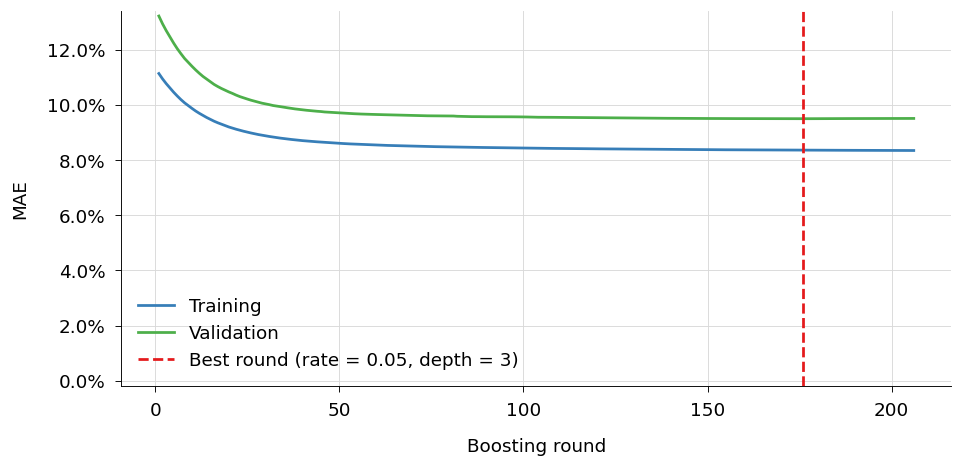

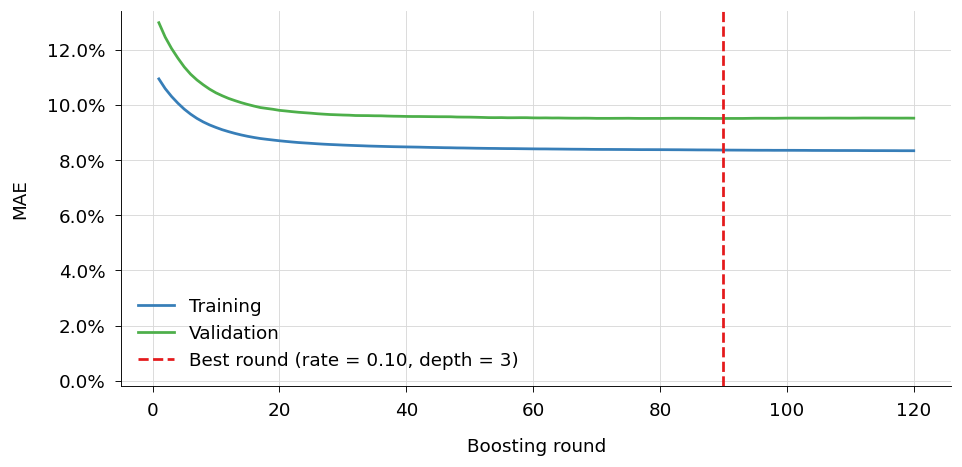

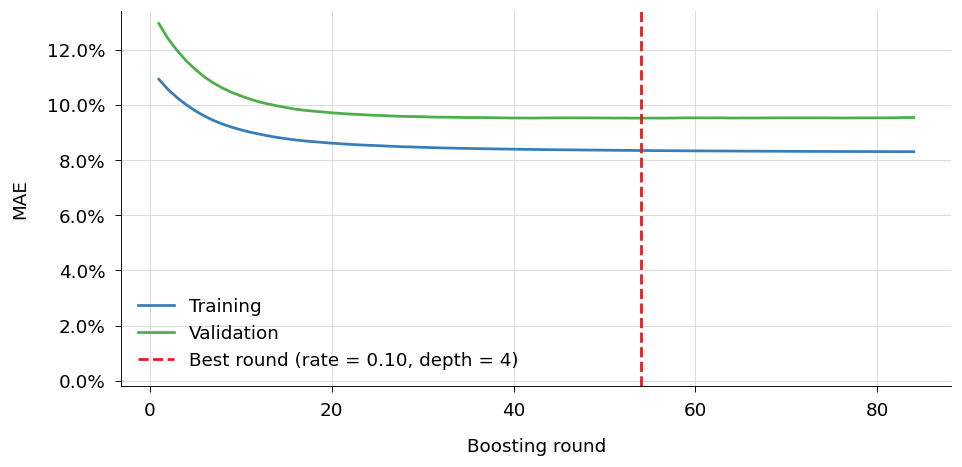

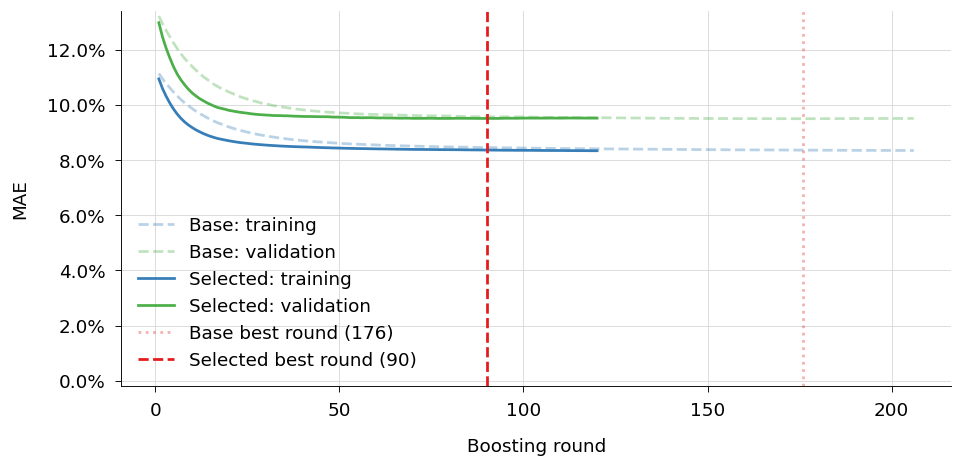

In [12]:
all_errors = pd.concat([
    history[['training_mae', 'validation_mae']]
    for history in histories.values()
])
upper_limit = all_errors.max().max() + 0.002

for configuration in configurations:
    name = configuration['name']
    history = histories[name]
    best_round = int(
        xgb_results.loc[xgb_results['name'].eq(name), 'best_round'].item()
    )
    figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
    axis.plot(
        history['boosting_round'], history['training_mae'],
        color=COLOR_PALETTE[0], label='Training',
    )
    axis.plot(
        history['boosting_round'], history['validation_mae'],
        color=COLOR_PALETTE[2], label='Validation',
    )
    axis.axvline(
        best_round, color=COLOR_PALETTE[1],
        linestyle='--',
        label=(
            f"Best round (rate = {configuration['learning_rate']:.2f}, "
            f"depth = {configuration['max_depth']})"
        ),
    )
    axis.set_xlabel('Boosting round')
    axis.set_ylabel('MAE')
    axis.set_ylim(bottom=-0.002, top=upper_limit)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.legend()
    apply_matplotlib_layout(figure)
    figure.savefig(
        paths.figures / f'04_02_xgboost_{name}_learning_curve.pdf'
    )
    plt.show()

base_name = 'rate_005_depth_3'
selected_name = 'rate_010_depth_3'
base_history = histories[base_name]
selected_history = histories[selected_name]

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    base_history['boosting_round'], base_history['training_mae'],
    color=COLOR_PALETTE[0], linestyle='--', alpha=0.35,
    label='Base: training',
)
axis.plot(
    base_history['boosting_round'], base_history['validation_mae'],
    color=COLOR_PALETTE[2], linestyle='--', alpha=0.35,
    label='Base: validation',
)
axis.plot(
    selected_history['boosting_round'], selected_history['training_mae'],
    color=COLOR_PALETTE[0], label='Selected: training',
)
axis.plot(
    selected_history['boosting_round'], selected_history['validation_mae'],
    color=COLOR_PALETTE[2], label='Selected: validation',
)
base_best_round = int(
    xgb_results.loc[xgb_results['name'].eq(base_name), 'best_round'].item()
)
selected_best_round = int(
    xgb_results.loc[xgb_results['name'].eq(selected_name), 'best_round'].item()
)
axis.axvline(
    base_best_round, color=COLOR_PALETTE[1], linestyle=':', alpha=0.35,
    label=f'Base best round ({base_best_round})',
)
axis.axvline(
    selected_best_round, color=COLOR_PALETTE[1], linestyle='--',
    label=f'Selected best round ({selected_best_round})',
)
axis.set_xlabel('Boosting round')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002, top=upper_limit)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_02_xgboost_base_vs_selected_learning_curve.pdf'
)
plt.show()

## XGBoost configuration comparison

In [11]:
xgb_comparison = xgb_results[[
    'learning_rate', 'max_depth', 'best_round', 'training_mae',
    'mae', 'rmse', 'r2', 'mean_quarterly_spearman',
]].rename(columns={
    'mae': 'validation_mae',
    'rmse': 'validation_rmse',
    'r2': 'validation_r2',
})
xgb_comparison['generalization_gap'] = (
    xgb_comparison['validation_mae'] - xgb_comparison['training_mae']
)
xgb_comparison['selected'] = xgb_results['name'].eq(best_xgb['name'])
xgb_comparison = xgb_comparison[[
    'learning_rate', 'max_depth', 'best_round', 'training_mae',
    'validation_mae', 'generalization_gap', 'validation_rmse',
    'validation_r2', 'mean_quarterly_spearman', 'selected',
]]
xgb_comparison.to_csv(
    modeling_tables / 'xgboost_controlled_configuration_comparison.csv',
    index=False,
)
xgb_report_table = xgb_comparison.rename(columns={
    'learning_rate': 'Learning rate',
    'max_depth': 'Depth',
    'best_round': 'Best round',
    'training_mae': 'Training MAE',
    'validation_mae': 'Validation MAE',
    'generalization_gap': 'Gap',
    'validation_rmse': 'RMSE',
    'validation_r2': '$R^2$',
    'mean_quarterly_spearman': 'Spearman',
    'selected': 'Selected',
}).copy()
for column in ('Learning rate', 'Training MAE', 'Validation MAE', 'Gap', 'RMSE'):
    xgb_report_table[column] = xgb_report_table[column].map('{:.4f}'.format)
for column in ('$R^2$', 'Spearman'):
    xgb_report_table[column] = xgb_report_table[column].map('{:.3f}'.format)
xgb_report_table['Depth'] = xgb_report_table['Depth'].astype(int)
xgb_report_table['Best round'] = xgb_report_table['Best round'].astype(int)
xgb_report_table['Selected'] = xgb_report_table['Selected'].map({True: 'Yes', False: 'No'})
xgb_report_table.to_latex(
    paths.tables / '04_02_xgboost_configuration_comparison.tex',
    index=False,
    escape=False,
    caption='Validation performance of the controlled XGBoost configurations.',
    label='tab:xgboost-configuration-comparison',
)
display(xgb_comparison.style.format({
    'learning_rate': '{:.2f}',
    'max_depth': '{:.0f}',
    'best_round': '{:.0f}',
    'training_mae': '{:.4f}',
    'validation_mae': '{:.4f}',
    'generalization_gap': '{:.4f}',
    'validation_rmse': '{:.4f}',
    'validation_r2': '{:.3f}',
    'mean_quarterly_spearman': '{:.3f}',
}))

,learning_rate,max_depth,best_round,training_mae,validation_mae,generalization_gap,validation_rmse,validation_r2,mean_quarterly_spearman,selected
0,0.05,3,176,0.0836,0.0950,0.0114,0.1317,0.466,0.749,False
1,0.10,3,90,0.0836,0.0951,0.0114,0.1317,0.466,0.748,True
2,0.10,4,54,0.0835,0.0952,0.0117,0.1316,0.466,0.748,False
